# 04 - Clustering K-Means - Segmentation Utilisateurs

## 🎯 Objectif
Segmenter les utilisateurs en **profils culinaires distincts** via K-Means

## 📋 Étapes
1. ✅ Charger `users_profiles.csv` (depuis feature engineering)
2. ✅ Normaliser les features (StandardScaler)
3. ✅ Déterminer K optimal (elbow + silhouette)
4. ✅ Entraîner K-Means final
5. ✅ Analyser & interpréter les segments
6. ✅ Visualiser clusters (PCA)

## 📦 Input :
- **`users_profiles.csv`** : Profils utilisateurs (20 features)

## 📦 Output :
- **Clusters identifiés** + profils par segment
- **Visualisations** (elbow, silhouette, PCA)
- **users_profiles_clustered.csv** : Profils avec labels de clusters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set_style('whitegrid')
DATA_PROCESSED = Path('../data/processed')
OUTPUTS_FIGURES = Path('../outputs/figures')
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('✅ Imports & Configuration OK')
print(f'   📂 Data processed: {DATA_PROCESSED}')
print(f'   📂 Outputs figures: {OUTPUTS_FIGURES}')

✅ Imports & Configuration OK
   📂 Data processed: ../data/processed
   📂 Outputs figures: ../outputs/figures


## ÉTAPE 1 - Chargement des Profils Utilisateurs

In [2]:
print("=" * 80)
print("CHARGEMENT DES PROFILS UTILISATEURS")
print("=" * 80)

# Charger les profils créés par feature engineering
user_profiles = pd.read_csv(DATA_PROCESSED / 'users_profiles.csv')

print(f'\n📊 PROFILS CHARGÉS:')
print(f'   • Shape: {user_profiles.shape}')
print(f'   • Utilisateurs: {len(user_profiles):,}')
print(f'   • Features: {len(user_profiles.columns) - 1}')  # -1 pour user_id

print(f'\n📋 COLONNES ({len(user_profiles.columns)}):')
for i, col in enumerate(user_profiles.columns, 1):
    print(f'   {i:2d}. {col}')

print(f'\n📈 APERÇU:')
print(user_profiles.head())

print(f'\n📊 STATISTIQUES:')
print(user_profiles.describe())

CHARGEMENT DES PROFILS UTILISATEURS

📊 PROFILS CHARGÉS:
   • Shape: (15061, 20)
   • Utilisateurs: 15,061
   • Features: 19

📋 COLONNES (20):
    1. user_id
    2. n_interactions
    3. avg_rating
    4. avg_minutes
    5. avg_n_steps
    6. avg_n_ingredients
    7. avg_calories
    8. avg_total_fat
    9. avg_sugar
   10. avg_sodium
   11. avg_protein
   12. avg_saturated_fat
   13. avg_carbohydrates
   14. pref_tag_time_to_make
   15. pref_tag_course
   16. pref_tag_main_ingredient
   17. pref_tag_dietary
   18. pref_tag_easy
   19. pref_tag_occasion
   20. pref_tag_cuisine

📈 APERÇU:
   user_id  n_interactions  avg_rating  avg_minutes  avg_n_steps  \
0     1533             115    4.747826    83.137739     8.756522   
1     1535             649    4.476117    63.929800     8.469954   
2     1634              48    3.875000    35.208333     7.395833   
3     1676              24    4.583333    61.375000     9.333333   
4     1792              26    4.576923   160.224615     8.576923  

## ÉTAPE 2 - Normalisation des Features

In [ ]:
print("=" * 80)
print("NORMALISATION DES FEATURES")
print("=" * 80)

# Séparer user_id et features
user_ids = user_profiles['user_id'].copy()
features_cols = [col for col in user_profiles.columns if col != 'user_id']
features_raw = user_profiles[features_cols].copy()

print(f'\n📊 FEATURES À NORMALISER:')
print(f'   • Nombre: {len(features_cols)}')
print(f'   • Colonnes: {features_cols[:5]}... ({len(features_cols)} total)')

# Normalisation (StandardScaler)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_raw)
features_scaled_df = pd.DataFrame(features_scaled, columns=features_cols, index=user_ids)

print(f'\n✅ NORMALISATION TERMINÉE:')
print(f'   • Shape: {features_scaled_df.shape}')
print(f'   • Mean: {features_scaled_df.mean().mean():.6f} (proche de 0 ✓)')
print(f'   • Std: {features_scaled_df.std().mean():.6f} (proche de 1 ✓)')

print(f'\n📈 STATISTIQUES FEATURES NORMALISÉES:')
print(features_scaled_df.describe())



NORMALISATION DES FEATURES

📊 FEATURES À NORMALISER:
   • Nombre: 19
   • Colonnes: ['n_interactions', 'avg_rating', 'avg_minutes', 'avg_n_steps', 'avg_n_ingredients']... (19 total)

✅ NORMALISATION TERMINÉE:
   • Shape: (15061, 19)
   • Mean: -0.000000 (proche de 0 ✓)
   • Std: 1.000033 (proche de 1 ✓)

📈 STATISTIQUES FEATURES NORMALISÉES:

✅ NORMALISATION TERMINÉE:
   • Shape: (15061, 19)
   • Mean: -0.000000 (proche de 0 ✓)
   • Std: 1.000033 (proche de 1 ✓)

📈 STATISTIQUES FEATURES NORMALISÉES:
       n_interactions    avg_rating   avg_minutes   avg_n_steps  \
count    1.506100e+04  1.506100e+04  1.506100e+04  1.506100e+04   
mean     1.509685e-17 -4.566797e-16  3.396792e-17 -1.034134e-15   
std      1.000033e+00  1.000033e+00  1.000033e+00  1.000033e+00   
min     -2.533506e-01 -8.746438e+00 -1.552307e+00 -3.529418e+00   
25%     -2.405416e-01 -4.057658e-01 -6.907225e-01 -6.157393e-01   
50%     -2.021146e-01  2.275074e-01 -2.629040e-01 -5.142995e-02   
75%     -1.060470e-01  7.06

## ÉTAPE 3 - Déterminer K Optimal (Elbow + Silhouette)

In [4]:
print("=" * 80)
print("DÉTERMINATION DU K OPTIMAL")
print("=" * 80)

print(f'\n🔍 Test de K = 2 à 10...')

inertias = []
silhouette_scores_list = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(features_scaled_df)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(features_scaled_df, kmeans.labels_)
    silhouette_scores_list.append(sil_score)
    print(f'   K={k}: Inertia={kmeans.inertia_:>10,.2f}, Silhouette={sil_score:.4f}')

# Trouver le meilleur K (silhouette maximal)
best_k_silhouette = K_range[np.argmax(silhouette_scores_list)]
max_silhouette = max(silhouette_scores_list)

print(f'\n✅ K OPTIMAL (silhouette maximum):')
print(f'   • K = {best_k_silhouette}')
print(f'   • Silhouette score = {max_silhouette:.4f}')
print(f'   • Inertia = {inertias[best_k_silhouette-2]:,.2f}')

# Recommandation basée sur l'objectif (5 segments)
print(f'\n🎯 RECOMMANDATION:')
print(f'   • Objectif initial: K = 5 segments')
print(f'   • Silhouette pour K=5: {silhouette_scores_list[3]:.4f}')
print(f'   • Décision: K = {best_k_silhouette} (meilleur silhouette) ou K = 5 (objectif métier)')

best_k = best_k_silhouette  # On prend le meilleur silhouette

DÉTERMINATION DU K OPTIMAL

🔍 Test de K = 2 à 10...
   K=2: Inertia=250,711.93, Silhouette=0.1665
   K=2: Inertia=250,711.93, Silhouette=0.1665
   K=3: Inertia=233,181.47, Silhouette=0.0975
   K=3: Inertia=233,181.47, Silhouette=0.0975
   K=4: Inertia=222,501.89, Silhouette=0.0780
   K=4: Inertia=222,501.89, Silhouette=0.0780
   K=5: Inertia=213,306.07, Silhouette=0.0818
   K=5: Inertia=213,306.07, Silhouette=0.0818
   K=6: Inertia=204,647.13, Silhouette=0.0834
   K=6: Inertia=204,647.13, Silhouette=0.0834
   K=7: Inertia=198,155.55, Silhouette=0.0753
   K=7: Inertia=198,155.55, Silhouette=0.0753
   K=8: Inertia=192,210.45, Silhouette=0.0715
   K=8: Inertia=192,210.45, Silhouette=0.0715
   K=9: Inertia=186,889.51, Silhouette=0.0686
   K=9: Inertia=186,889.51, Silhouette=0.0686
   K=10: Inertia=182,425.02, Silhouette=0.0557

✅ K OPTIMAL (silhouette maximum):
   • K = 2
   • Silhouette score = 0.1665
   • Inertia = 250,711.93

🎯 RECOMMANDATION:
   • Objectif initial: K = 5 segments
   • 

## ÉTAPE 4 - Visualisation Elbow & Silhouette

VISUALISATION ELBOW & SILHOUETTE


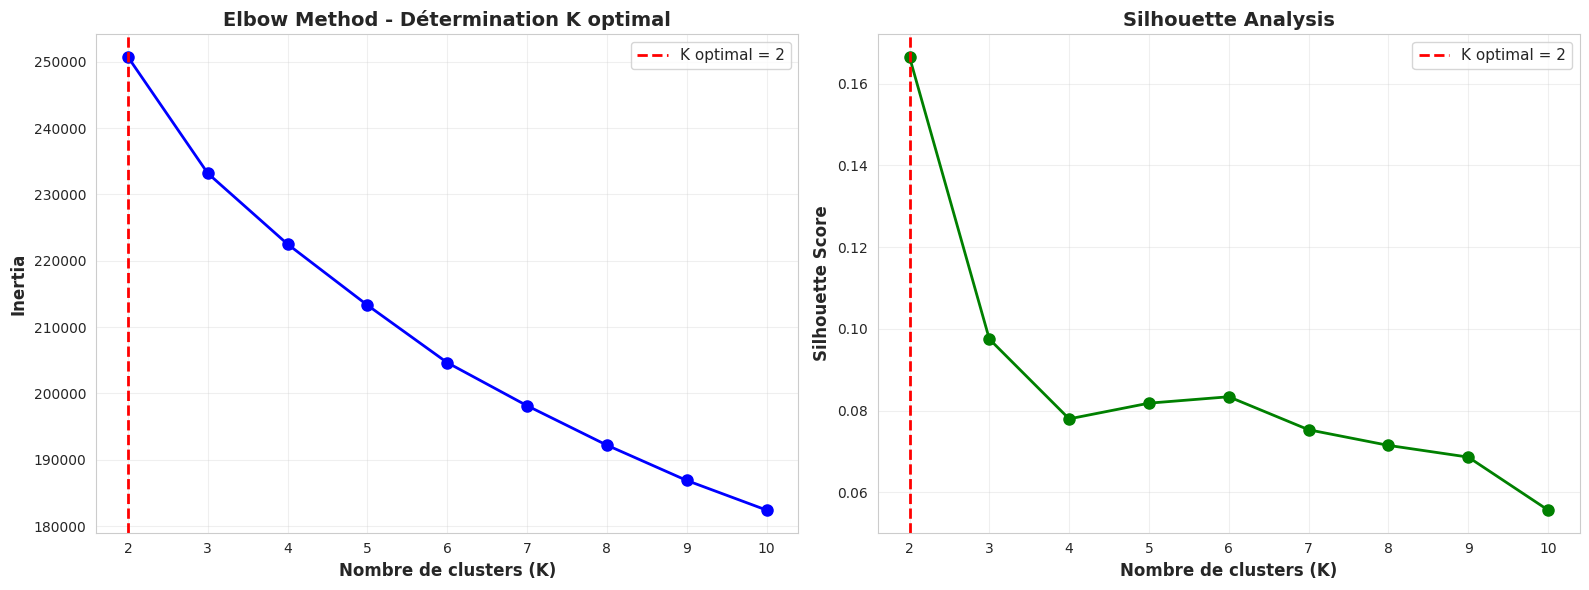


✅ Graphiques sauvegardés: ../outputs/figures/01_elbow_silhouette.png


In [5]:
print("=" * 80)
print("VISUALISATION ELBOW & SILHOUETTE")
print("=" * 80)

# Visualisation Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[0].set_xlabel('Nombre de clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - Détermination K optimal', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores_list, 'go-', linewidth=2, markersize=8)
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[1].set_xlabel('Nombre de clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '01_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Graphiques sauvegardés: {OUTPUTS_FIGURES / "01_elbow_silhouette.png"}')

## ÉTAPE 5 - Entraînement K-Means Final

In [6]:
print("=" * 80)
print(f"ENTRAÎNEMENT K-MEANS FINAL (K={best_k})")
print("=" * 80)

# Entraîner K-Means avec K optimal
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=50, max_iter=300)
clusters = kmeans_final.fit_predict(features_scaled_df)

# Ajouter les clusters aux dataframes
features_raw['cluster'] = clusters
features_scaled_df['cluster'] = clusters
user_profiles['cluster'] = clusters

print(f'\n✅ K-MEANS ENTRAÎNÉ:')
print(f'   • Nombre de clusters: {best_k}')
print(f'   • Inertia finale: {kmeans_final.inertia_:,.2f}')
final_silhouette = silhouette_score(features_scaled_df.drop("cluster", axis=1), clusters)
print(f'   • Silhouette score: {final_silhouette:.4f}')

print(f'\n📊 DISTRIBUTION DES CLUSTERS:')
cluster_counts = user_profiles['cluster'].value_counts().sort_index()
for cluster_id in range(best_k):
    count = cluster_counts[cluster_id]
    pct = 100 * count / len(user_profiles)
    print(f'   Cluster {cluster_id}: {count:>6,} utilisateurs ({pct:>5.1f}%)')

print(f'\n   Total: {len(user_profiles):,} utilisateurs')

ENTRAÎNEMENT K-MEANS FINAL (K=2)

✅ K-MEANS ENTRAÎNÉ:
   • Nombre de clusters: 2
   • Inertia finale: 250,711.23

✅ K-MEANS ENTRAÎNÉ:
   • Nombre de clusters: 2
   • Inertia finale: 250,711.23
   • Silhouette score: 0.1653

📊 DISTRIBUTION DES CLUSTERS:
   Cluster 0:  4,227 utilisateurs ( 28.1%)
   Cluster 1: 10,834 utilisateurs ( 71.9%)

   Total: 15,061 utilisateurs
   • Silhouette score: 0.1653

📊 DISTRIBUTION DES CLUSTERS:
   Cluster 0:  4,227 utilisateurs ( 28.1%)
   Cluster 1: 10,834 utilisateurs ( 71.9%)

   Total: 15,061 utilisateurs


## ÉTAPE 6 - Profiler Chaque Cluster

PROFILS DES CLUSTERS

📊 PROFILS PAR CLUSTER:


🔵 CLUSTER 0 (4,227 utilisateurs - 28.1%)
--------------------------------------------------------------------------------
   n_interactions                :    23.4
   avg_rating                    :     4.5
   avg_minutes                   :    88.9
   avg_n_steps                   :     9.3
   avg_n_ingredients             :     9.3
   avg_calories                  :   608.5
   avg_protein                   :    44.8
   avg_sugar                     :   106.2
   pref_tag_easy                 :   0.523 (proportion)
   pref_tag_dietary              :   0.845 (proportion)
   pref_tag_time_to_make         :   0.986 (proportion)

🔵 CLUSTER 1 (10,834 utilisateurs - 71.9%)
--------------------------------------------------------------------------------
   n_interactions                :    52.8
   avg_rating                    :     4.5
   avg_minutes                   :    75.8
   avg_n_steps                   :     8.9
   avg_n_ingredients   

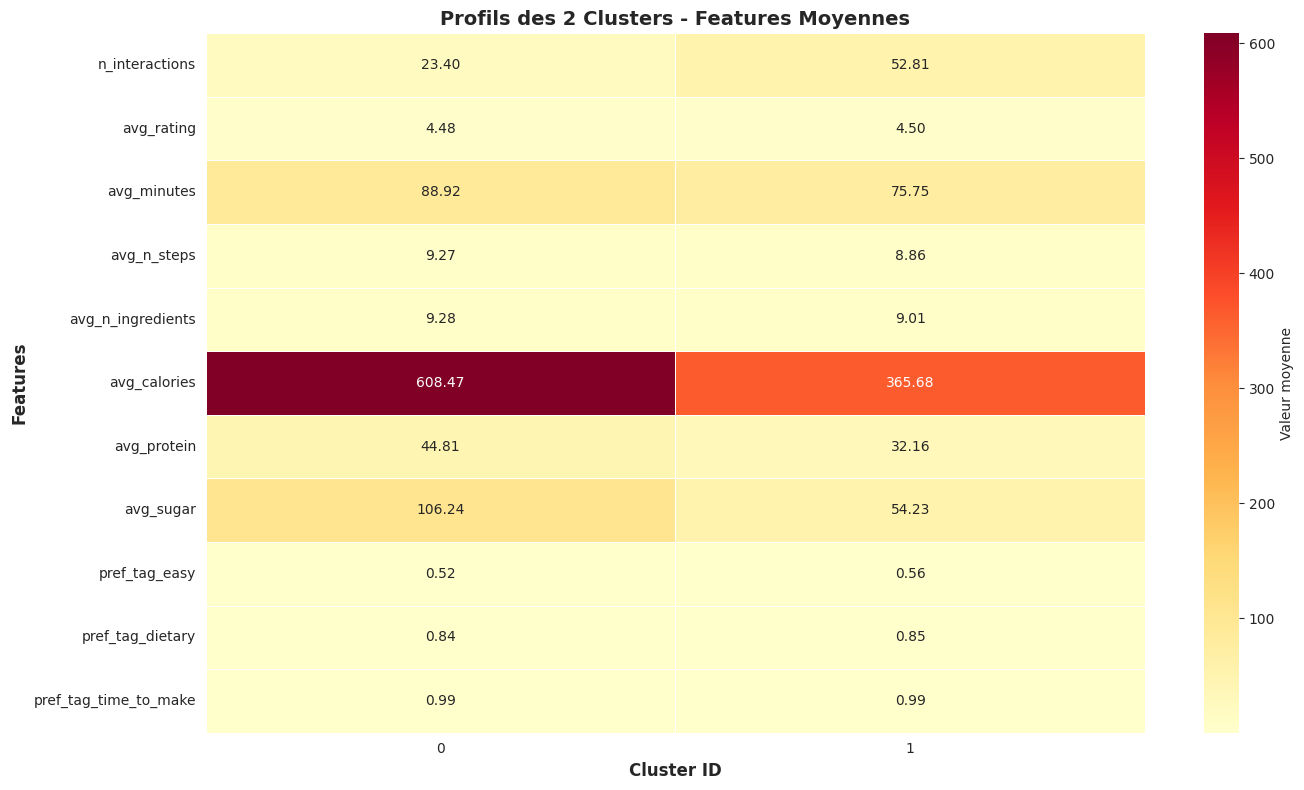


✅ Heatmap sauvegardée: ../outputs/figures/02_cluster_profiles_heatmap.png


In [7]:
print("=" * 80)
print("PROFILS DES CLUSTERS")
print("=" * 80)

# Sélectionner les features principales pour le profiling
features_to_show = [
    'n_interactions', 'avg_rating', 
    'avg_minutes', 'avg_n_steps', 'avg_n_ingredients',
    'avg_calories', 'avg_protein', 'avg_sugar',
    'pref_tag_easy', 'pref_tag_dietary', 'pref_tag_time_to_make'
]

# Calculer les moyennes par cluster
cluster_profiles = user_profiles.groupby('cluster')[features_to_show].mean()

print(f'\n📊 PROFILS PAR CLUSTER:\n')

for cluster_id in range(best_k):
    cluster_size = len(user_profiles[user_profiles['cluster'] == cluster_id])
    pct = cluster_size / len(user_profiles) * 100
    
    print(f'\n🔵 CLUSTER {cluster_id} ({cluster_size:,} utilisateurs - {pct:.1f}%)')
    print('-' * 80)
    
    for feature in features_to_show:
        value = cluster_profiles.loc[cluster_id, feature]
        
        # Format adapté au type de feature
        if feature.startswith('pref_'):
            print(f'   {feature:30s}: {value:>7.3f} (proportion)')
        elif feature.startswith('avg_'):
            print(f'   {feature:30s}: {value:>7.1f}')
        else:
            print(f'   {feature:30s}: {value:>7.1f}')

# Heatmap des profils
print(f'\n📊 HEATMAP DES PROFILS:')
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Valeur moyenne'}, linewidths=0.5)
plt.title(f'Profils des {best_k} Clusters - Features Moyennes', fontsize=14, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '02_cluster_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Heatmap sauvegardée: {OUTPUTS_FIGURES / "02_cluster_profiles_heatmap.png"}')

## ÉTAPE 7 - Visualisation PCA

VISUALISATION PCA

✅ PCA RÉALISÉE:
   • Variance expliquée totale: 34.1%
   • PC1: 22.0%
   • PC2: 12.1%


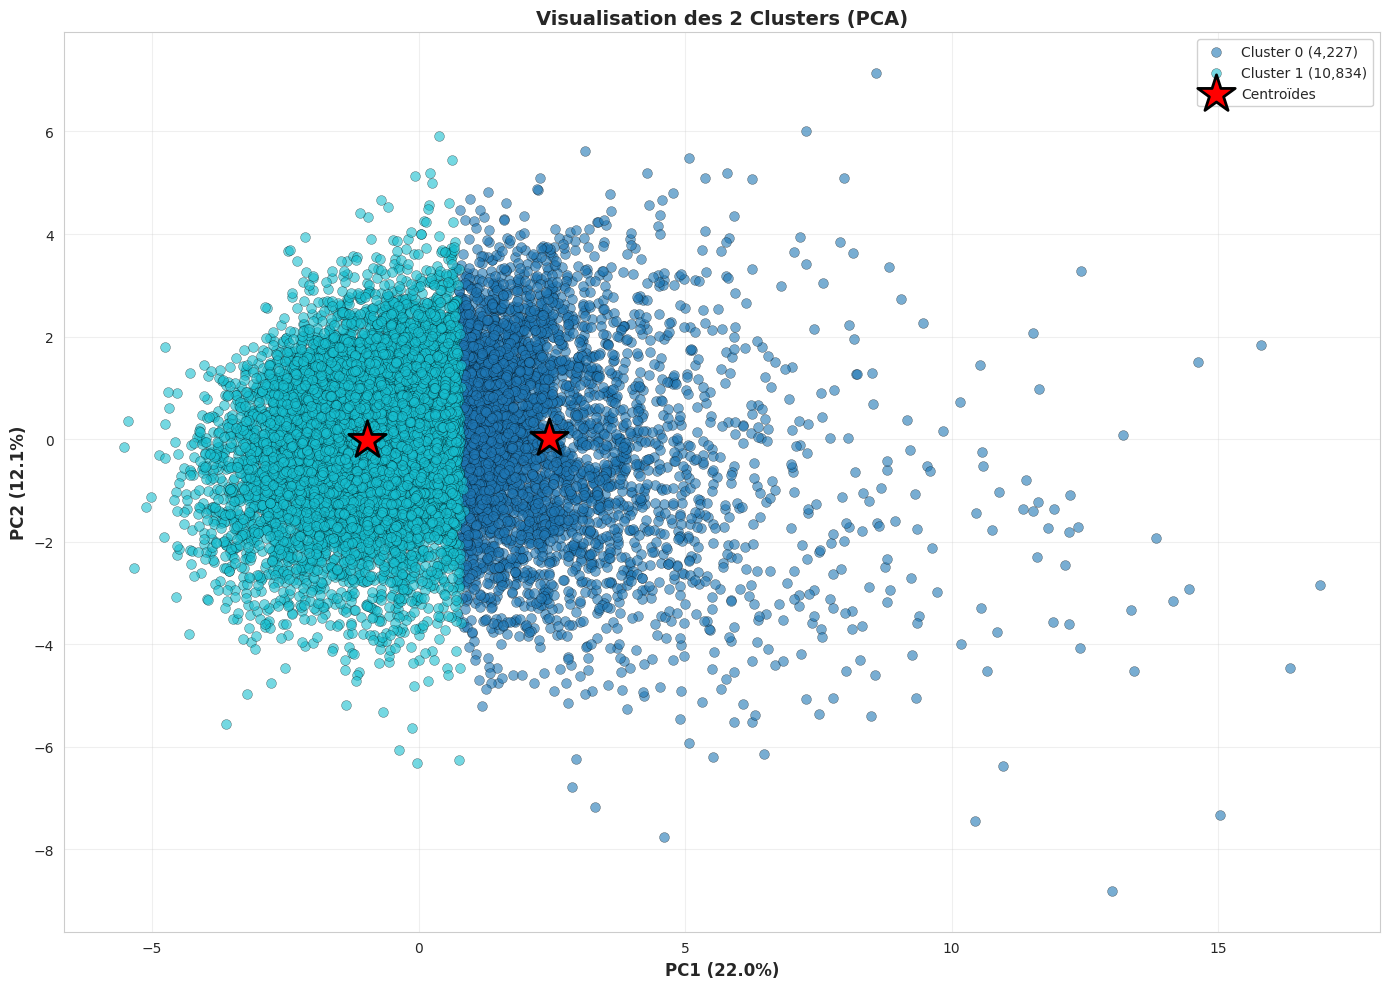


✅ Visualisation PCA sauvegardée: ../outputs/figures/03_clusters_pca.png


In [8]:
print("=" * 80)
print("VISUALISATION PCA")
print("=" * 80)

# Réduction dimensionnelle PCA pour visualisation
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled_df.drop('cluster', axis=1))

print(f'\n✅ PCA RÉALISÉE:')
print(f'   • Variance expliquée totale: {pca.explained_variance_ratio_.sum():.1%}')
print(f'   • PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'   • PC2: {pca.explained_variance_ratio_[1]:.1%}')

# Visualisation
fig, ax = plt.subplots(figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, best_k))
for cluster_id in range(best_k):
    mask = user_profiles['cluster'] == cluster_id
    ax.scatter(features_pca[mask, 0], features_pca[mask, 1], 
              label=f'Cluster {cluster_id} ({mask.sum():,})', 
              alpha=0.6, s=50, color=colors[cluster_id], edgecolors='black', linewidth=0.3)

# Centroïdes
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
          c='red', marker='*', s=800, edgecolors='black', linewidth=2, label='Centroïdes', zorder=10)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title(f'Visualisation des {best_k} Clusters (PCA)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '03_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Visualisation PCA sauvegardée: {OUTPUTS_FIGURES / "03_clusters_pca.png"}')

## ÉTAPE 8 - Export des Résultats

In [9]:
print("=" * 80)
print("EXPORT DES RÉSULTATS")
print("=" * 80)

# Export des profils avec clusters
output_file = DATA_PROCESSED / 'users_profiles_clustered.csv'
user_profiles.to_csv(output_file, index=False)

print(f'\n✅ FICHIER EXPORTÉ:')
print(f'   • Chemin: {output_file}')
print(f'   • Shape: {user_profiles.shape}')
print(f'   • Taille: {output_file.stat().st_size / 1024 / 1024:.2f} MB')

print(f'\n📋 COLONNES ({len(user_profiles.columns)}):')
for i, col in enumerate(user_profiles.columns, 1):
    print(f'   {i:2d}. {col}')

print(f'\n✅ Dataset avec clusters prêt pour analyse et recommandations!')

EXPORT DES RÉSULTATS

✅ FICHIER EXPORTÉ:
   • Chemin: ../data/processed/users_profiles_clustered.csv
   • Shape: (15061, 21)
   • Taille: 3.51 MB

📋 COLONNES (21):
    1. user_id
    2. n_interactions
    3. avg_rating
    4. avg_minutes
    5. avg_n_steps
    6. avg_n_ingredients
    7. avg_calories
    8. avg_total_fat
    9. avg_sugar
   10. avg_sodium
   11. avg_protein
   12. avg_saturated_fat
   13. avg_carbohydrates
   14. pref_tag_time_to_make
   15. pref_tag_course
   16. pref_tag_main_ingredient
   17. pref_tag_dietary
   18. pref_tag_easy
   19. pref_tag_occasion
   20. pref_tag_cuisine
   21. cluster

✅ Dataset avec clusters prêt pour analyse et recommandations!

✅ FICHIER EXPORTÉ:
   • Chemin: ../data/processed/users_profiles_clustered.csv
   • Shape: (15061, 21)
   • Taille: 3.51 MB

📋 COLONNES (21):
    1. user_id
    2. n_interactions
    3. avg_rating
    4. avg_minutes
    5. avg_n_steps
    6. avg_n_ingredients
    7. avg_calories
    8. avg_total_fat
    9. avg_suga

## 📋 Synthèse Finale

In [10]:
print("\n" + "=" * 80)
print("🎉 SYNTHÈSE FINALE - CLUSTERING K-MEANS")
print("=" * 80)

print(f'\n🎯 OBJECTIF ATTEINT:')
print(f'   Segmenter les utilisateurs en {best_k} profils culinaires distincts')

print(f'\n📊 DONNÉES:')
print(f'   • Utilisateurs: {len(user_profiles):,}')
print(f'   • Features: {len(features_cols)}')

print(f'\n🔧 RÉSULTATS K-MEANS:')
print(f'   • K optimal (silhouette): {best_k}')
print(f'   • Silhouette score: {final_silhouette:.4f}')
print(f'   • Inertia: {kmeans_final.inertia_:,.2f}')

print(f'\n📊 DISTRIBUTION DES CLUSTERS:')
for cluster_id in range(best_k):
    count = cluster_counts[cluster_id]
    pct = 100 * count / len(user_profiles)
    print(f'   Cluster {cluster_id}: {count:>6,} utilisateurs ({pct:>5.1f}%)')

print(f'\n📦 FICHIERS GÉNÉRÉS:')
print(f'   1. users_profiles_clustered.csv')
print(f'   2. 01_elbow_silhouette.png')
print(f'   3. 02_cluster_profiles_heatmap.png')
print(f'   4. 03_clusters_pca.png')

print(f'\n🎯 PROCHAINES ÉTAPES:')
print(f'   1. Interpréter les profils culinaires de chaque cluster')
print(f'   2. Nommer les segments (ex: "Gourmand", "Healthy", "Rapide", etc.)')
print(f'   3. Créer système de recommandations basé sur les clusters')
print(f'   4. Valider avec métriques business')

print("=" * 80)


🎉 SYNTHÈSE FINALE - CLUSTERING K-MEANS

🎯 OBJECTIF ATTEINT:
   Segmenter les utilisateurs en 2 profils culinaires distincts

📊 DONNÉES:
   • Utilisateurs: 15,061
   • Features: 19

🔧 RÉSULTATS K-MEANS:
   • K optimal (silhouette): 2
   • Silhouette score: 0.1653
   • Inertia: 250,711.23

📊 DISTRIBUTION DES CLUSTERS:
   Cluster 0:  4,227 utilisateurs ( 28.1%)
   Cluster 1: 10,834 utilisateurs ( 71.9%)

📦 FICHIERS GÉNÉRÉS:
   1. users_profiles_clustered.csv
   2. 01_elbow_silhouette.png
   3. 02_cluster_profiles_heatmap.png
   4. 03_clusters_pca.png

🎯 PROCHAINES ÉTAPES:
   1. Interpréter les profils culinaires de chaque cluster
   2. Nommer les segments (ex: "Gourmand", "Healthy", "Rapide", etc.)
   3. Créer système de recommandations basé sur les clusters
   4. Valider avec métriques business
